In [5]:
import os

# Create the destination directory if it doesn't exist
!mkdir -p /content/local_dataset/

# Unzip the file locally. Enclose the filename in quotes due to spaces and parentheses.
!unzip -q "/content/archive (3).zip" -d /content/local_dataset/

print("Dataset copied to local high-speed storage!")

Dataset copied to local high-speed storage!


In [33]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, Flatten, BatchNormalization, Activation
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# 1. DATA LOADERS (Strictly 48x48 Grayscale)
train_dir = '/content/local_dataset/train'
test_dir = '/content/local_dataset/test'
TARGET_CLASSES = ['angry', 'happy', 'neutral', 'sad']

train_datagen = ImageDataGenerator(rescale=1./255, horizontal_flip=True)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=(48, 48), color_mode="grayscale",
    batch_size=64, class_mode='categorical', classes=TARGET_CLASSES)

test_generator = test_datagen.flow_from_directory(
    test_dir, target_size=(48, 48), color_mode="grayscale",
    batch_size=64, class_mode='categorical', classes=TARGET_CLASSES)

# Class weights to prevent bias
class_weights = compute_class_weight('balanced', classes=np.unique(train_generator.classes), y=train_generator.classes)
class_weight_dict = dict(enumerate(class_weights))

# 2. THE NATIVE FER MODEL
model = Sequential([
    Conv2D(64, (3, 3), padding='same', input_shape=(48, 48, 1)),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    Conv2D(128, (5, 5), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    Conv2D(512, (3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    Flatten(),
    Dense(256),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    Dense(4, activation='softmax')
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy', metrics=['accuracy'])

# 3. TRAINING
print("Starting Native Grayscale Training...")
early_stop = EarlyStopping(monitor='val_accuracy', patience=6, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

history = model.fit(train_generator, epochs=30, validation_data=test_generator,
                    class_weight=class_weight_dict, callbacks=[early_stop, reduce_lr])

Found 21005 images belonging to 4 classes.
Found 5212 images belonging to 4 classes.
Starting Native Grayscale Training...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 30s 61ms/step - accuracy: 0.4051 - loss: 1.4307 - val_accuracy: 0.2761 - val_loss: 1.3831 - learning_rate: 0.0010
Epoch 2/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.5471 - loss: 1.0924 - val_accuracy: 0.4906 - val_loss: 1.1093 - learning_rate: 0.0010
Epoch 3/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - accuracy: 0.5926 - loss: 0.9922 - val_accuracy: 0.4238 - val_loss: 1.4094 - learning_rate: 0.0010
Epoch 4/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - accuracy: 0.6234 - loss: 0.9409 - val_accuracy: 0.5723 - val_loss: 0.9998 - learning_rate: 0.0010
Epoch 5/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.6386 - loss: 0.9061 - val_accuracy: 0.5288 - val_loss: 1.0613 - learning_rate: 0.0010
Epoch 6/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.6474 - loss: 0.8825 - val_accuracy: 0.6314 - val_loss: 0.8801 - learning_rate: 0.0010
Epoch 7/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - accuracy: 0.6590 - l

<IPython.core.display.Javascript object>

--- PREDICTION RESULTS ---
Dominant Emotion: HAPPY
Intensity Level: 90.12%

Full Spectrum Analysis:
- Angry: 0.0%
- Happy: 90.1%
- Neutral: 9.8%
- Sad: 0.1%


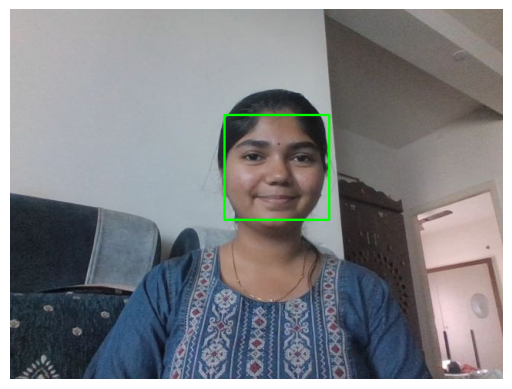

In [42]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
import cv2
import numpy as np
import base64
from PIL import Image
import io
import tensorflow as tf
import matplotlib.pyplot as plt

# JavaScript to access the webcam
def take_photo(filename='photo.jpg', quality=0.8):
  js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

      const btn = document.createElement('button');
      btn.textContent = 'Capture Frame';
      div.appendChild(btn);
      await new Promise((resolve) => btn.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getVideoTracks()[0].stop();
      div.remove();
      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
  display(js)
  data = eval_js('takePhoto({})'.format(quality))
  binary = base64.b64decode(data.split(',')[1])
  with open(filename, 'wb') as f:
    f.write(binary)
  return filename

try:
  filename = take_photo()
  img = cv2.imread(filename)

  # Everything operates in pure grayscale now
  gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
  img_rgb_display = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

  face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
  faces = face_cascade.detectMultiScale(gray, 1.3, 5)

  if len(faces) == 0:
      print("No face detected in the frame. Please try again.")
  else:
      for (x, y, w, h) in faces:
          cv2.rectangle(img_rgb_display, (x, y), (x+w, y+h), (0, 255, 0), 2)

          # 1. Simple crop
          roi_gray = gray[y:y+h, x:x+w]

          # 2. Resize to 48x48
          roi_resized = cv2.resize(roi_gray, (48, 48))

          # 3. Format for our Native CNN
          img_pixels = tf.keras.preprocessing.image.img_to_array(roi_resized)
          img_pixels = np.expand_dims(img_pixels, axis=0)
          img_pixels /= 255.0 # Basic normalization

          # 4. Predict
          predictions = model.predict(img_pixels, verbose=0)[0]
          max_index = np.argmax(predictions)

          emotion_labels = ['angry', 'happy', 'neutral', 'sad']
          predicted_emotion = emotion_labels[max_index]
          intensity = predictions[max_index] * 100

          print(f"--- PREDICTION RESULTS ---")
          print(f"Dominant Emotion: {predicted_emotion.upper()}")
          print(f"Intensity Level: {intensity:.2f}%\n")

          print("Full Spectrum Analysis:")
          for i in range(len(emotion_labels)):
              print(f"- {emotion_labels[i].capitalize()}: {predictions[i]*100:.1f}%")

          plt.imshow(img_rgb_display)
          plt.axis('off')
          plt.show()

except Exception as err:
  print(f"An error occurred: {str(err)}")